In [1]:
from langchain_ollama import ChatOllama
from langchain_community.tools import TavilySearchResults
from langchain_core.tools import tool
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph import START

from datetime import datetime
from typing import Annotated
from typing_extensions import TypedDict

from dotenv import load_dotenv
_=load_dotenv()





In [2]:
# bruker lokalt installert Ollama modell
llm = ChatOllama(
    model="llama3.1",
    temperature=0.7,
)


In [3]:
# Tavility søke verktøy
tavility_search_results = TavilySearchResults(max_results=2)

# henter dagens dato

@tool
def get_current_date() -> str:
    """Returns the current date in YYYY-MM-DD format."""
    return f"Today's date is {datetime.now().strftime('%Y-%m-%d')}"

/var/folders/hj/x4wfx_bs4q34dvmpj96hnctm0000gn/T/ipykernel_18742/301464130.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavility_search_results = TavilySearchResults(max_results=2)


In [4]:
tools = [tavility_search_results, get_current_date]


In [5]:
llm_with_tools = llm.bind_tools(tools)

In [6]:
# Uten reducer: overstyrer hele listen
#state["messages"] = [new_message]  # ❌ gamle meldinger er borte

# Med add_messages reducer: slår sammen intelligent  
#state["messages"] = old_messages + [new_message]  # ✅ bevarer historikk


# lager tilstand for agenten, som inkluderer en liste over meldinger
class State(TypedDict):
    """State of the agent."""
    messages: Annotated[list, add_messages]

In [7]:
# definerer en node
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [8]:
graph_builder = StateGraph(State)

In [9]:
graph_builder.add_node("chatbot", chatbot)

In [10]:
# Legger til tools som node og legger til graph
tool_node=ToolNode(tools=tools)
graph_builder.add_node("tool_node", tool_node)

In [11]:
## kun kjøre en gang
graph_builder.add_conditional_edges(
    "chatbot", 
    tools_condition,
    {"tools": "tool_node", "__end__": "__end__"}
)

In [12]:
graph_builder.add_edge("tool_node", "chatbot")

In [13]:
graph_builder.add_edge(START, "chatbot")

In [14]:
# kompilerer graphen til en agent
graph = graph_builder.compile()


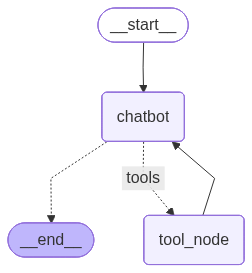

In [15]:
from IPython.display import display, Image
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Could not render graph:", e)


In [16]:
from IPython.display import Markdown, display

def render_markdown(md_string):
    display(Markdown(md_string))

def process_stream(stream):
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()
    return message

def process_query(query, config=None):
    inputs = {"messages": [("user", query)]}
    message = process_stream(graph.stream(inputs, config, stream_mode="values"))
    render_markdown(f"## Answer:\n{message.content}")

In [17]:
process_query("What can you do?")

================================ Human Message =================================

What can you do?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (615766c4-10c8-4fd4-b100-08130d3d0a77)
 Call ID: 615766c4-10c8-4fd4-b100-08130d3d0a77
  Args:
    query: What can you do?
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "What Is a Digital Assistant?", "url": "https://librestream.com/blog/what-is-a-digital-assistant", "content": "### Personal Assistance\n\nOne of the primary roles of a digital assistant is to serve as a personal helper. Users can ask their digital assistants to perform tasks like setting alarms, scheduling meetings, sending messages, and making phone calls. This hands-free convenience allows users to manage their daily activities more efficiently, freeing up time for more important tasks.\n\n### Information Retrieval\n\nDigit

## Answer:
Based on the search results, it appears that I can perform a variety of tasks and provide information to users. Some of my capabilities include:

* Personal assistance: I can help with tasks such as setting alarms, scheduling meetings, sending messages, and making phone calls.
* Information retrieval: I can quickly retrieve information on topics such as weather forecasts, directions, restaurants, and stock prices.
* Smart home control: I can be integrated with smart home devices to control lights, thermostats, and other appliances.
* Answering complex questions: I can understand context and provide answers to complex questions.
* Anticipating user needs: I can anticipate what users need and provide personalized services.

Overall, my primary goal is to serve as a personal helper and make tasks easier for users.

In [18]:
process_query("hent siste kurs til Tesla?")

================================ Human Message =================================

hent siste kurs til Tesla?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (488d7d83-fe17-4920-ba93-c38c80a9b466)
 Call ID: 488d7d83-fe17-4920-ba93-c38c80a9b466
  Args:
    query: Tesla siste kurs
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Tesla: TSLA Stock Price Quote & News | Robinhood", "url": "https://robinhood.com/us/en/stocks/TSLA", "content": "As of 2026-05-21, Tesla(TSLA) stock has fluctuated between $419.05 and $426.95. The current price stands at $419.17, placing the stock +0.0% above today's low and -1.8% off the high.\n\nTesla(TSLA) shares are trading with a volume of 7.48M, against a daily average of 57.96M.\n\nIn the last year, Tesla(TSLA) shares hit a 52-week high of $498.83 and a 52-week low of $273.21.\n\nIn the last year, Tesla(TSLA

## Answer:
Basert på den siste informasjonen jeg har fått, er dagens kurs for Tesla $419.17.

In [20]:
process_query("Er det noen gode elver å fiske i nært Senja")

================================ Human Message =================================

Er det noen gode elver å fiske i nært Senja
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (fc73a130-6750-4037-94a6-9e89f6e9eb44)
 Call ID: fc73a130-6750-4037-94a6-9e89f6e9eb44
  Args:
    query: gode elver å fiske på Senja
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Lakselva på Senja | Norske Lakseelver", "url": "https://lakseelver.no/nb/elv-om-fisket/2021/lakselva-pa-senja", "content": "From June 15th to September 14th midnight (00:00) the maximum of three (3) single hooks or one (1) triple hook regardless tackle type.\n\nForbidden to use shrimp, bait fish, or otter.\n\nForbidden to use gaff to land salmon.\n\nFrom July 20th the use of wobbler, and kinds of lures in the river is forbidden.\n\nMaximum two (2) fishing poles per boat, however only one

## Answer:
Det er flere gode elver å fiske på Senja, blant annet Lakselva på Senja. Det er forskjellige regler for fisking på ulike tidspunkter av året og det er viktig å følge disse for å sikre en god og lovlig fangst.

Lakselva på Senja har en spesiell fiskeordning som gjelder fra 15. juni til 14. september, hvor det er tillatt å fiske med maksimalt tre enkeltkroker eller én trippelkrok. Det er også forbud mot bruk av reke, agnfisk og oter.

Det er flere båtoperatører på Senja som tilbyr fiskeeksperienser med profesjonelle båter og utstyr. Disse operatørene har erfaring og kunnskap om lokale fiskebestander og kan hjelpe deg å få en suksessfull fangst.

Det er også mulighet for å fiske i havområdene på Nord-Senja, hvor det ofte er stor fisk som tas. Men dette krever at du har din egen båt og utstyr, samt erfaring med fiske i saltvann.

I alle fall er det viktig å følge lokale regler og bestemmelser for fisking på Senja, samt å være respektfull overfor andre fiskere og den lokale miljøet.